# Customer Churn Prediction
### Step 2 — Model Training, Evaluation & Comparison
> **Prerequisite:** Run Step 1 notebook first, or run the preprocessing cell below.

## 📦 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('✓ All libraries imported')


✓ All libraries imported


## ♻️ Step 1 Recap — Preprocessing (run this to load clean data)

In [2]:
# Full preprocessing pipeline from Step 1
df = pd.read_csv('customer_churn_data.csv')
df.drop(columns=['CustomerID'], inplace=True)
df['InternetService'] = df['InternetService'].fillna('No Service')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
le = LabelEncoder()
df['Gender']      = le.fit_transform(df['Gender'])
df['TechSupport'] = df['TechSupport'].map({'No': 0, 'Yes': 1})
df = pd.get_dummies(df, columns=['ContractType', 'InternetService'], drop_first=False)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df['AvgMonthlySpend'] = df.apply(
    lambda r: r['TotalCharges'] / r['Tenure'] if r['Tenure'] > 0 else r['MonthlyCharges'], axis=1)
df['ChargeDeviation'] = abs(df['MonthlyCharges'] - df['AvgMonthlySpend'])

X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = ['Age','Tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend','ChargeDeviation']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f'✓ Data ready  |  X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'  Churn rate  →  Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}')


✓ Data ready  |  X_train: (800, 14)  |  X_test: (200, 14)
  Churn rate  →  Train: 0.882  |  Test: 0.885


## ⚠️ Why We Don't Use Accuracy Here

Our dataset has **88.3% churn (Yes)** and only **11.7% non-churn (No)**.

A model that predicts *everyone churns* would get **88% accuracy** — but it's completely useless.

| Metric | What it measures | Why it matters here |
|---|---|---|
| **F1-Score** | Balance of precision + recall | Best single metric for imbalanced data |
| **ROC-AUC** | Ability to rank churners above non-churners | Threshold-independent performance |
| **Precision** | Of all predicted churners, how many actually churn | Avoid wasting retention budget on wrong people |
| **Recall** | Of all actual churners, how many did we catch | Missing a churner = lost customer |
| **PR-AUC** | Area under precision-recall curve | Best metric when classes are highly imbalanced |


## 🤖 Step 2.1 — Define Models with Class Imbalance Handling

In [3]:
# class_weight='balanced' tells the model to pay more attention
# to the minority class (No-churn = 11.7%) during training.
# Without this, the model ignores minority class to minimize overall loss.

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_estimators=100,
        max_depth=10
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1
    )
}

print('✓ 3 models defined')
for name in models:
    print(f'   → {name}')


✓ 3 models defined
   → Logistic Regression
   → Random Forest
   → Gradient Boosting


## 🏋️ Step 2.2 — Train All Models

In [4]:
trained_models = {}
results = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred      = model.predict(X_test)
    y_proba     = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'f1'       : f1_score(y_test, y_pred, average='weighted'),
        'f1_macro' : f1_score(y_test, y_pred, average='macro'),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall'   : recall_score(y_test, y_pred, average='weighted'),
        'roc_auc'  : roc_auc_score(y_test, y_proba),
        'pr_auc'   : average_precision_score(y_test, y_proba),
    }
    print(f'done ✓  |  F1={results[name]["f1"]:.4f}  ROC-AUC={results[name]["roc_auc"]:.4f}')


Training Logistic Regression... done ✓  |  F1=0.9409  ROC-AUC=0.9926
Training Random Forest... done ✓  |  F1=1.0000  ROC-AUC=1.0000
Training Gradient Boosting... done ✓  |  F1=1.0000  ROC-AUC=1.0000


## 📊 Step 2.3 — Model Comparison Table

In [5]:
comparison = pd.DataFrame({
    name: {
        'F1 (weighted)' : round(r['f1'], 4),
        'F1 (macro)'    : round(r['f1_macro'], 4),
        'Precision'     : round(r['precision'], 4),
        'Recall'        : round(r['recall'], 4),
        'ROC-AUC'       : round(r['roc_auc'], 4),
        'PR-AUC'        : round(r['pr_auc'], 4),
    }
    for name, r in results.items()
}).T

# Highlight best value per column
comparison.style.highlight_max(axis=0, color='#d4edda')


,F1 (weighted),F1 (macro),Precision,Recall,ROC-AUC,PR-AUC
Logistic Regression,0.940900,0.870800,0.958500,0.935000,0.992600,0.999100
Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Gradient Boosting,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 📈 Step 2.4 — Visual Comparison

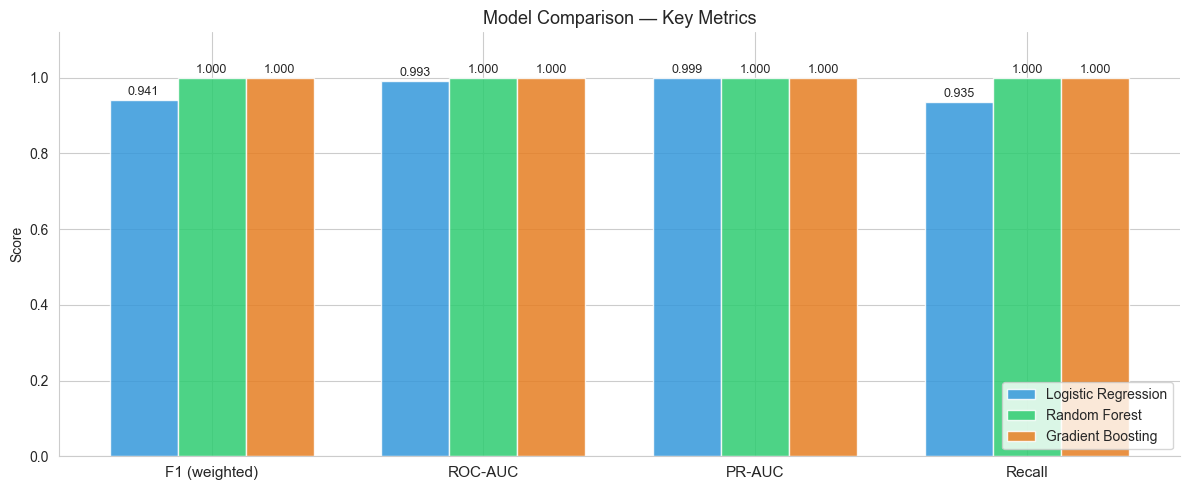

In [6]:
metrics   = ['F1 (weighted)', 'ROC-AUC', 'PR-AUC', 'Recall']
model_names = list(results.keys())
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498DB', '#2ECC71', '#E67E22']

fig, ax = plt.subplots(figsize=(12, 5))

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [
        results[name]['f1'],
        results[name]['roc_auc'],
        results[name]['pr_auc'],
        results[name]['recall'],
    ]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Key Metrics', fontsize=13)
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()


## 🔲 Step 2.5 — Confusion Matrices

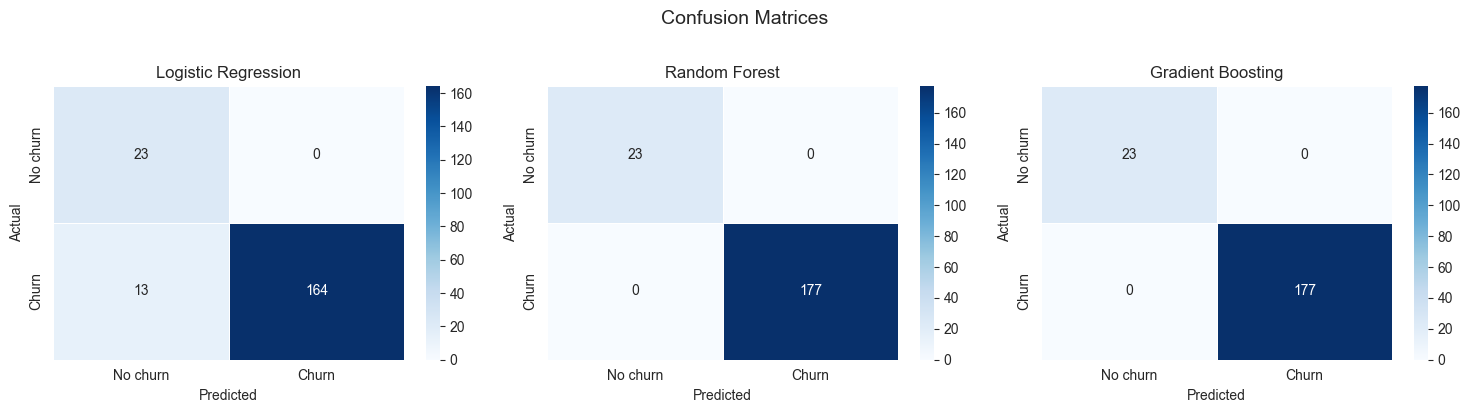


Reading a confusion matrix:
  Top-left  (TN) = correctly predicted 'No churn'
  Top-right (FP) = predicted churn but actually didn't  → wasted retention effort
  Bot-left  (FN) = predicted no-churn but actually did  → MISSED churner (costly!)
  Bot-right (TP) = correctly predicted churn



In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No churn', 'Churn'],
                yticklabels=['No churn', 'Churn'],
                linewidths=0.5)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("""
Reading a confusion matrix:
  Top-left  (TN) = correctly predicted 'No churn'
  Top-right (FP) = predicted churn but actually didn't  → wasted retention effort
  Bot-left  (FN) = predicted no-churn but actually did  → MISSED churner (costly!)
  Bot-right (TP) = correctly predicted churn
""")


## 📋 Step 2.6 — Detailed Classification Reports

In [9]:
for name, r in results.items():
    #print(f'{'─'*50}')
    print(f'  {name}')
    #print(f'{'─'*50}')
    print(classification_report(y_test, r['y_pred'],
                                 target_names=['No Churn (0)', 'Churn (1)']))


  Logistic Regression
              precision    recall  f1-score   support

No Churn (0)       0.64      1.00      0.78        23
   Churn (1)       1.00      0.93      0.96       177

    accuracy                           0.94       200
   macro avg       0.82      0.96      0.87       200
weighted avg       0.96      0.94      0.94       200

  Random Forest
              precision    recall  f1-score   support

No Churn (0)       1.00      1.00      1.00        23
   Churn (1)       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

  Gradient Boosting
              precision    recall  f1-score   support

No Churn (0)       1.00      1.00      1.00        23
   Churn (1)       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg    

## 📉 Step 2.7 — ROC Curves

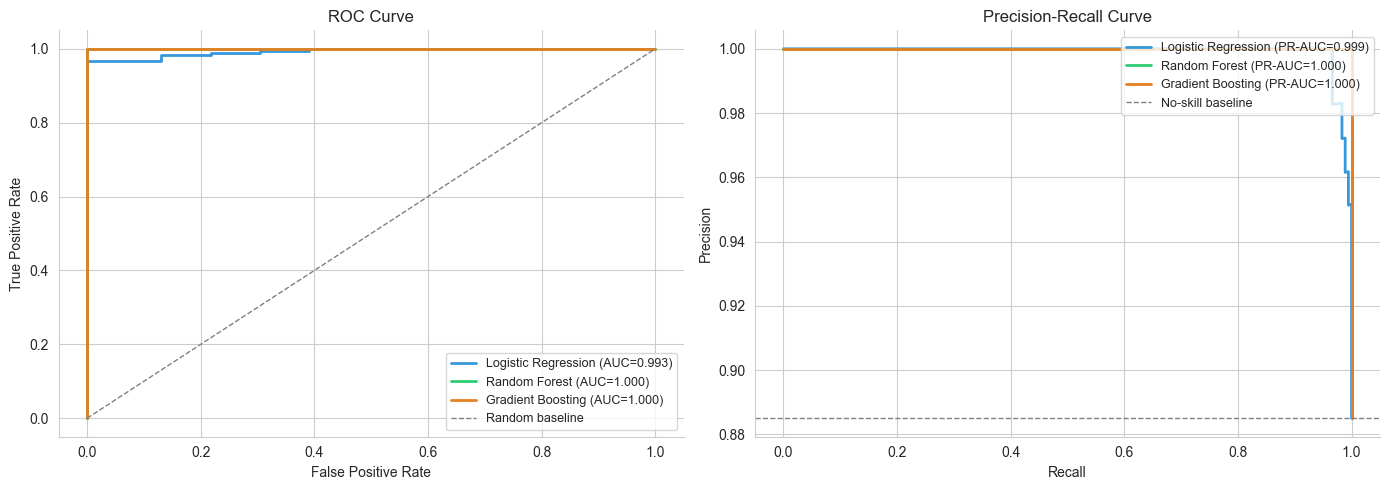

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498DB', '#2ECC71', '#E67E22']

# ROC curve
ax = axes[0]
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})", color=color, lw=2)
ax.plot([0,1],[0,1],'--', color='gray', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right', fontsize=9)
sns.despine()

# Precision-Recall curve
ax = axes[1]
for (name, r), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    ax.plot(rec, prec, label=f"{name} (PR-AUC={r['pr_auc']:.3f})", color=color, lw=2)
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1, label='No-skill baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(loc='upper right', fontsize=9)
sns.despine()

plt.tight_layout()
plt.show()


## 🔁 Step 2.8 — Cross-Validation (5-fold)

In [11]:
# Cross-validation gives a more reliable estimate of performance
# than a single train/test split. It trains 5 times on different splits
# and averages the results — reduces luck factor.

print(f"{'Model':<25} {'CV F1 Mean':>12} {'CV F1 Std':>12} {'CV AUC Mean':>13}")
print('─' * 65)

for name, model in trained_models.items():
    cv_f1  = cross_val_score(model, X, y, cv=5, scoring='f1_weighted')
    cv_auc = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    print(f"{name:<25} {cv_f1.mean():>12.4f} {cv_f1.std():>12.4f} {cv_auc.mean():>13.4f}")


Model                       CV F1 Mean    CV F1 Std   CV AUC Mean
─────────────────────────────────────────────────────────────────
Logistic Regression             0.9095       0.0149        0.9843
Random Forest                   0.9969       0.0062        1.0000
Gradient Boosting               1.0000       0.0000        1.0000


## 🔍 Step 2.9 — Feature Importance (Random Forest)

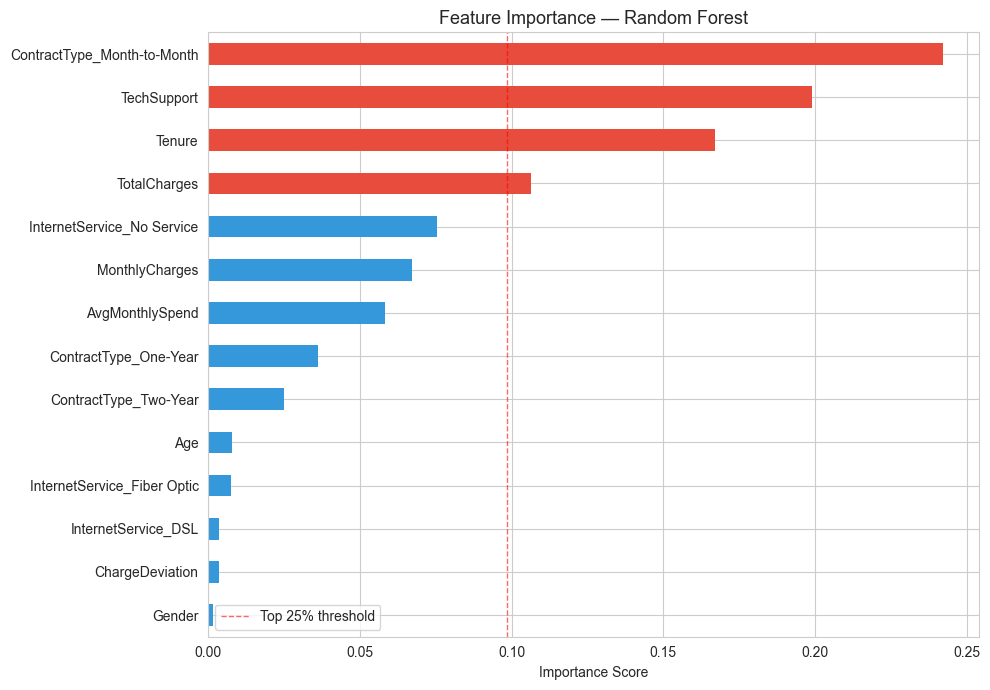


Top 5 most important features:
  ContractType_Month-to-Month         0.2421
  TechSupport                         0.1991
  Tenure                              0.1671
  TotalCharges                        0.1063
  InternetService_No Service          0.0755


In [12]:
rf_model = trained_models['Random Forest']
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors_bar = ['#E74C3C' if v > importances.quantile(0.75) else '#3498DB'
              for v in importances]
importances.plot(kind='barh', color=colors_bar, edgecolor='none')
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.axvline(x=importances.quantile(0.75), color='red',
            linestyle='--', lw=1, alpha=0.6, label='Top 25% threshold')
plt.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
for feat, score in importances.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<35} {score:.4f}')


## 🏆 Step 2.10 — Pick Best Model & Save It

In [13]:
import joblib

# Pick best model by ROC-AUC
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best_model = trained_models[best_name]

print(f'✓ Best model: {best_name}')
print(f'  ROC-AUC : {results[best_name]["roc_auc"]:.4f}')
print(f'  F1 Score: {results[best_name]["f1"]:.4f}')
print(f'  PR-AUC  : {results[best_name]["pr_auc"]:.4f}')

# Save the model and scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print()
print('✓ Saved: best_model.pkl')
print('✓ Saved: scaler.pkl')
print()
print('Next step → Step 3: Hyperparameter Tuning + SHAP Explainability')


✓ Best model: Random Forest
  ROC-AUC : 1.0000
  F1 Score: 1.0000
  PR-AUC  : 1.0000

✓ Saved: best_model.pkl
✓ Saved: scaler.pkl

Next step → Step 3: Hyperparameter Tuning + SHAP Explainability


## ✅ Step 2 Summary

In [14]:
print('='*55)
print('STEP 2 — MODEL TRAINING COMPLETE')
print('='*55)
print()
print('  Models trained      : Logistic Regression,')
print('                        Random Forest,')
print('                        Gradient Boosting')
print()
print('  Imbalance handling  : class_weight=balanced')
print('  Evaluation metrics  : F1, ROC-AUC, PR-AUC')
print('  Validation method   : Train/test split + 5-fold CV')
print()
print('  Files saved:')
print('    best_model.pkl  ← trained model')
print('    scaler.pkl      ← fitted scaler (use for new data)')
print()
print('  Next → Step 3: Hyperparameter tuning + SHAP explanations')


STEP 2 — MODEL TRAINING COMPLETE

  Models trained      : Logistic Regression,
                        Random Forest,
                        Gradient Boosting

  Imbalance handling  : class_weight=balanced
  Evaluation metrics  : F1, ROC-AUC, PR-AUC
  Validation method   : Train/test split + 5-fold CV

  Files saved:
    best_model.pkl  ← trained model
    scaler.pkl      ← fitted scaler (use for new data)

  Next → Step 3: Hyperparameter tuning + SHAP explanations
